In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from datetime import datetime
import plotly.express as px
from datetime import datetime

mpl.rc('font',family='Malgun Gothic')

url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)
df.to_csv('BostonHousing.csv', index=False)

| Column | Description |
|--------|-------------|
| CRIM | 도시별 1인당 범죄율 |
| ZN | 25,000 평방피트 이상의 구획으로 나뉜 주거용 토지 비율 |
| INDUS | 도시별 비소매 상업지역 면적 비율 |
| CHAS | 찰스강 더미 변수 (강과 경계가 닿으면 1, 아니면 0) |
| NOX | 일산화질소 농도 (천만분의 1) |
| RM | 주거지당 평균 방의 개수 |
| AGE | 1940년 이전에 건축된 자가소유 주택의 비율 |
| DIS | 보스턴의 5개 고용센터까지의 가중 거리 |
| RAD | 방사형 고속도로 접근성 지수 |
| TAX | $10,000당 재산세율 |
| PTRATIO | 도시별 학생-교사 비율 |
| B | 1000(Bk - 0.63)^2, Bk는 도시별 흑인 비율 |
| LSTAT | 하위계층 비율(%) |
| MEDV | 자가주택의 중앙값 ($1,000 단위) |

In [7]:
df

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [5]:
df['crim'].value_counts()


crim
0.01501     2
14.33370    2
0.03466     1
0.03113     1
0.03049     1
           ..
1.51902     1
1.83377     1
1.46336     1
1.27346     1
0.04741     1
Name: count, Length: 504, dtype: int64

In [8]:
df_corr = df.corr(numeric_only=True)
df_corr


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
crim,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
zn,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
indus,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
chas,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
nox,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
rm,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
age,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
dis,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
rad,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
tax,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


c:\conda\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()


<Axes: >

c:\conda\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  func(*args, **kwargs)
c:\conda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


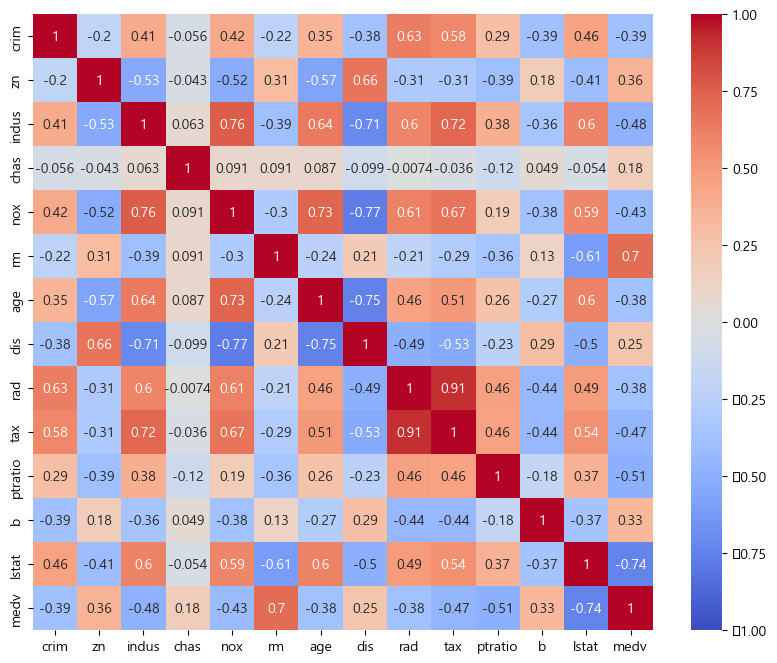

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(df_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)


In [22]:
bins = pd.cut(df['crim'], bins=5)  # 범죄율을 5개 구간으로 나눔
labels = ['매우낮음', '낮음', '중간', '높음', '매우높음']  
df['crim_bin'] = pd.cut(df['crim'], bins=5, labels=labels)
avg_price_by_crime = df.groupby('crim_bin')['medv'].agg('mean')
print('\n범죄율 구간별 평균 주택가격:')
pd.DataFrame(avg_price_by_crime).reset_index()



범죄율 구간별 평균 주택가격:


C:\Users\키움디지털아카데미\AppData\Local\Temp\ipykernel_24632\791599687.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_price_by_crime = df.groupby('crim_bin')['medv'].agg('mean')


,crim_bin,medv
0,매우낮음,23.114079
1,낮음,11.126667
2,중간,9.280000
3,높음,5.000000
4,매우높음,9.600000


#### 주택가격이 낮을수록 범죄율이 높음

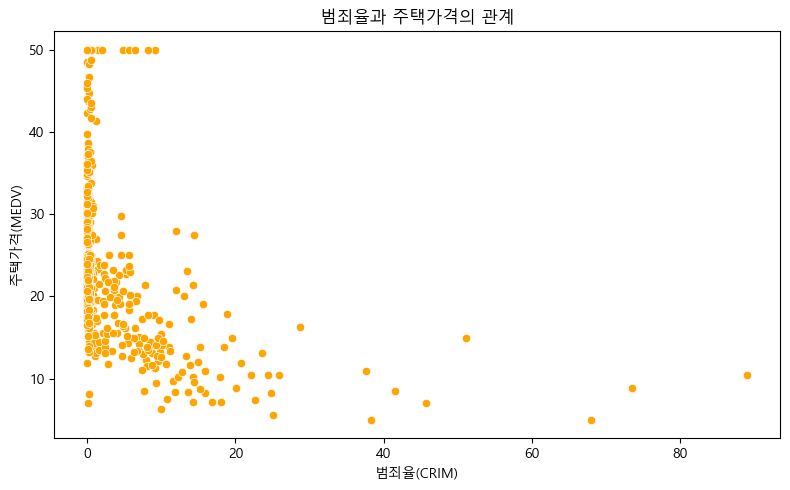

In [33]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='crim', y='medv',color='orange')
plt.title('범죄율과 주택가격의 관계')
plt.xlabel('범죄율(CRIM)')
plt.ylabel('주택가격(MEDV)')
plt.tight_layout()
plt.show()

### 방 개수가 많을수록 주택가격이 높음

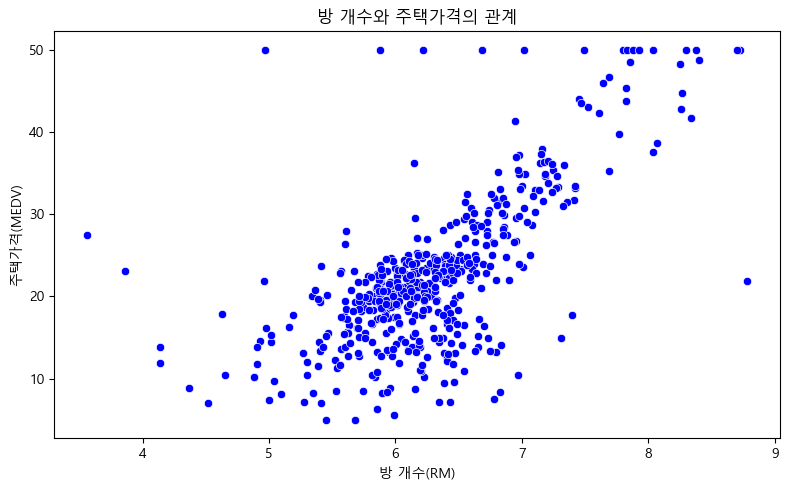

In [31]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='rm', y='medv',color='blue')
plt.title('방 개수와 주택가격의 관계')
plt.xlabel('방 개수(RM)')
plt.ylabel('주택가격(MEDV)')
plt.tight_layout()
plt.show()



In [34]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


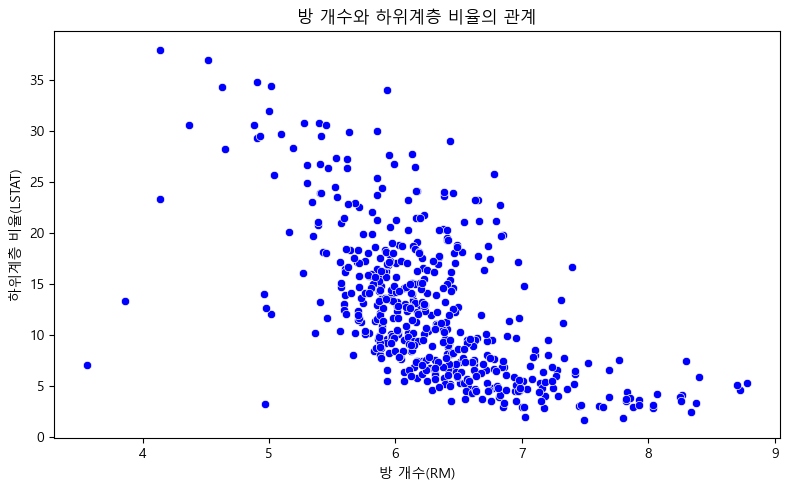

In [37]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='rm', y='lstat',color='blue')
plt.title('방 개수와 하위계층 비율의 관계')
plt.xlabel('방 개수(RM)')
plt.ylabel('하위계층 비율(LSTAT)')
plt.tight_layout()
plt.show()




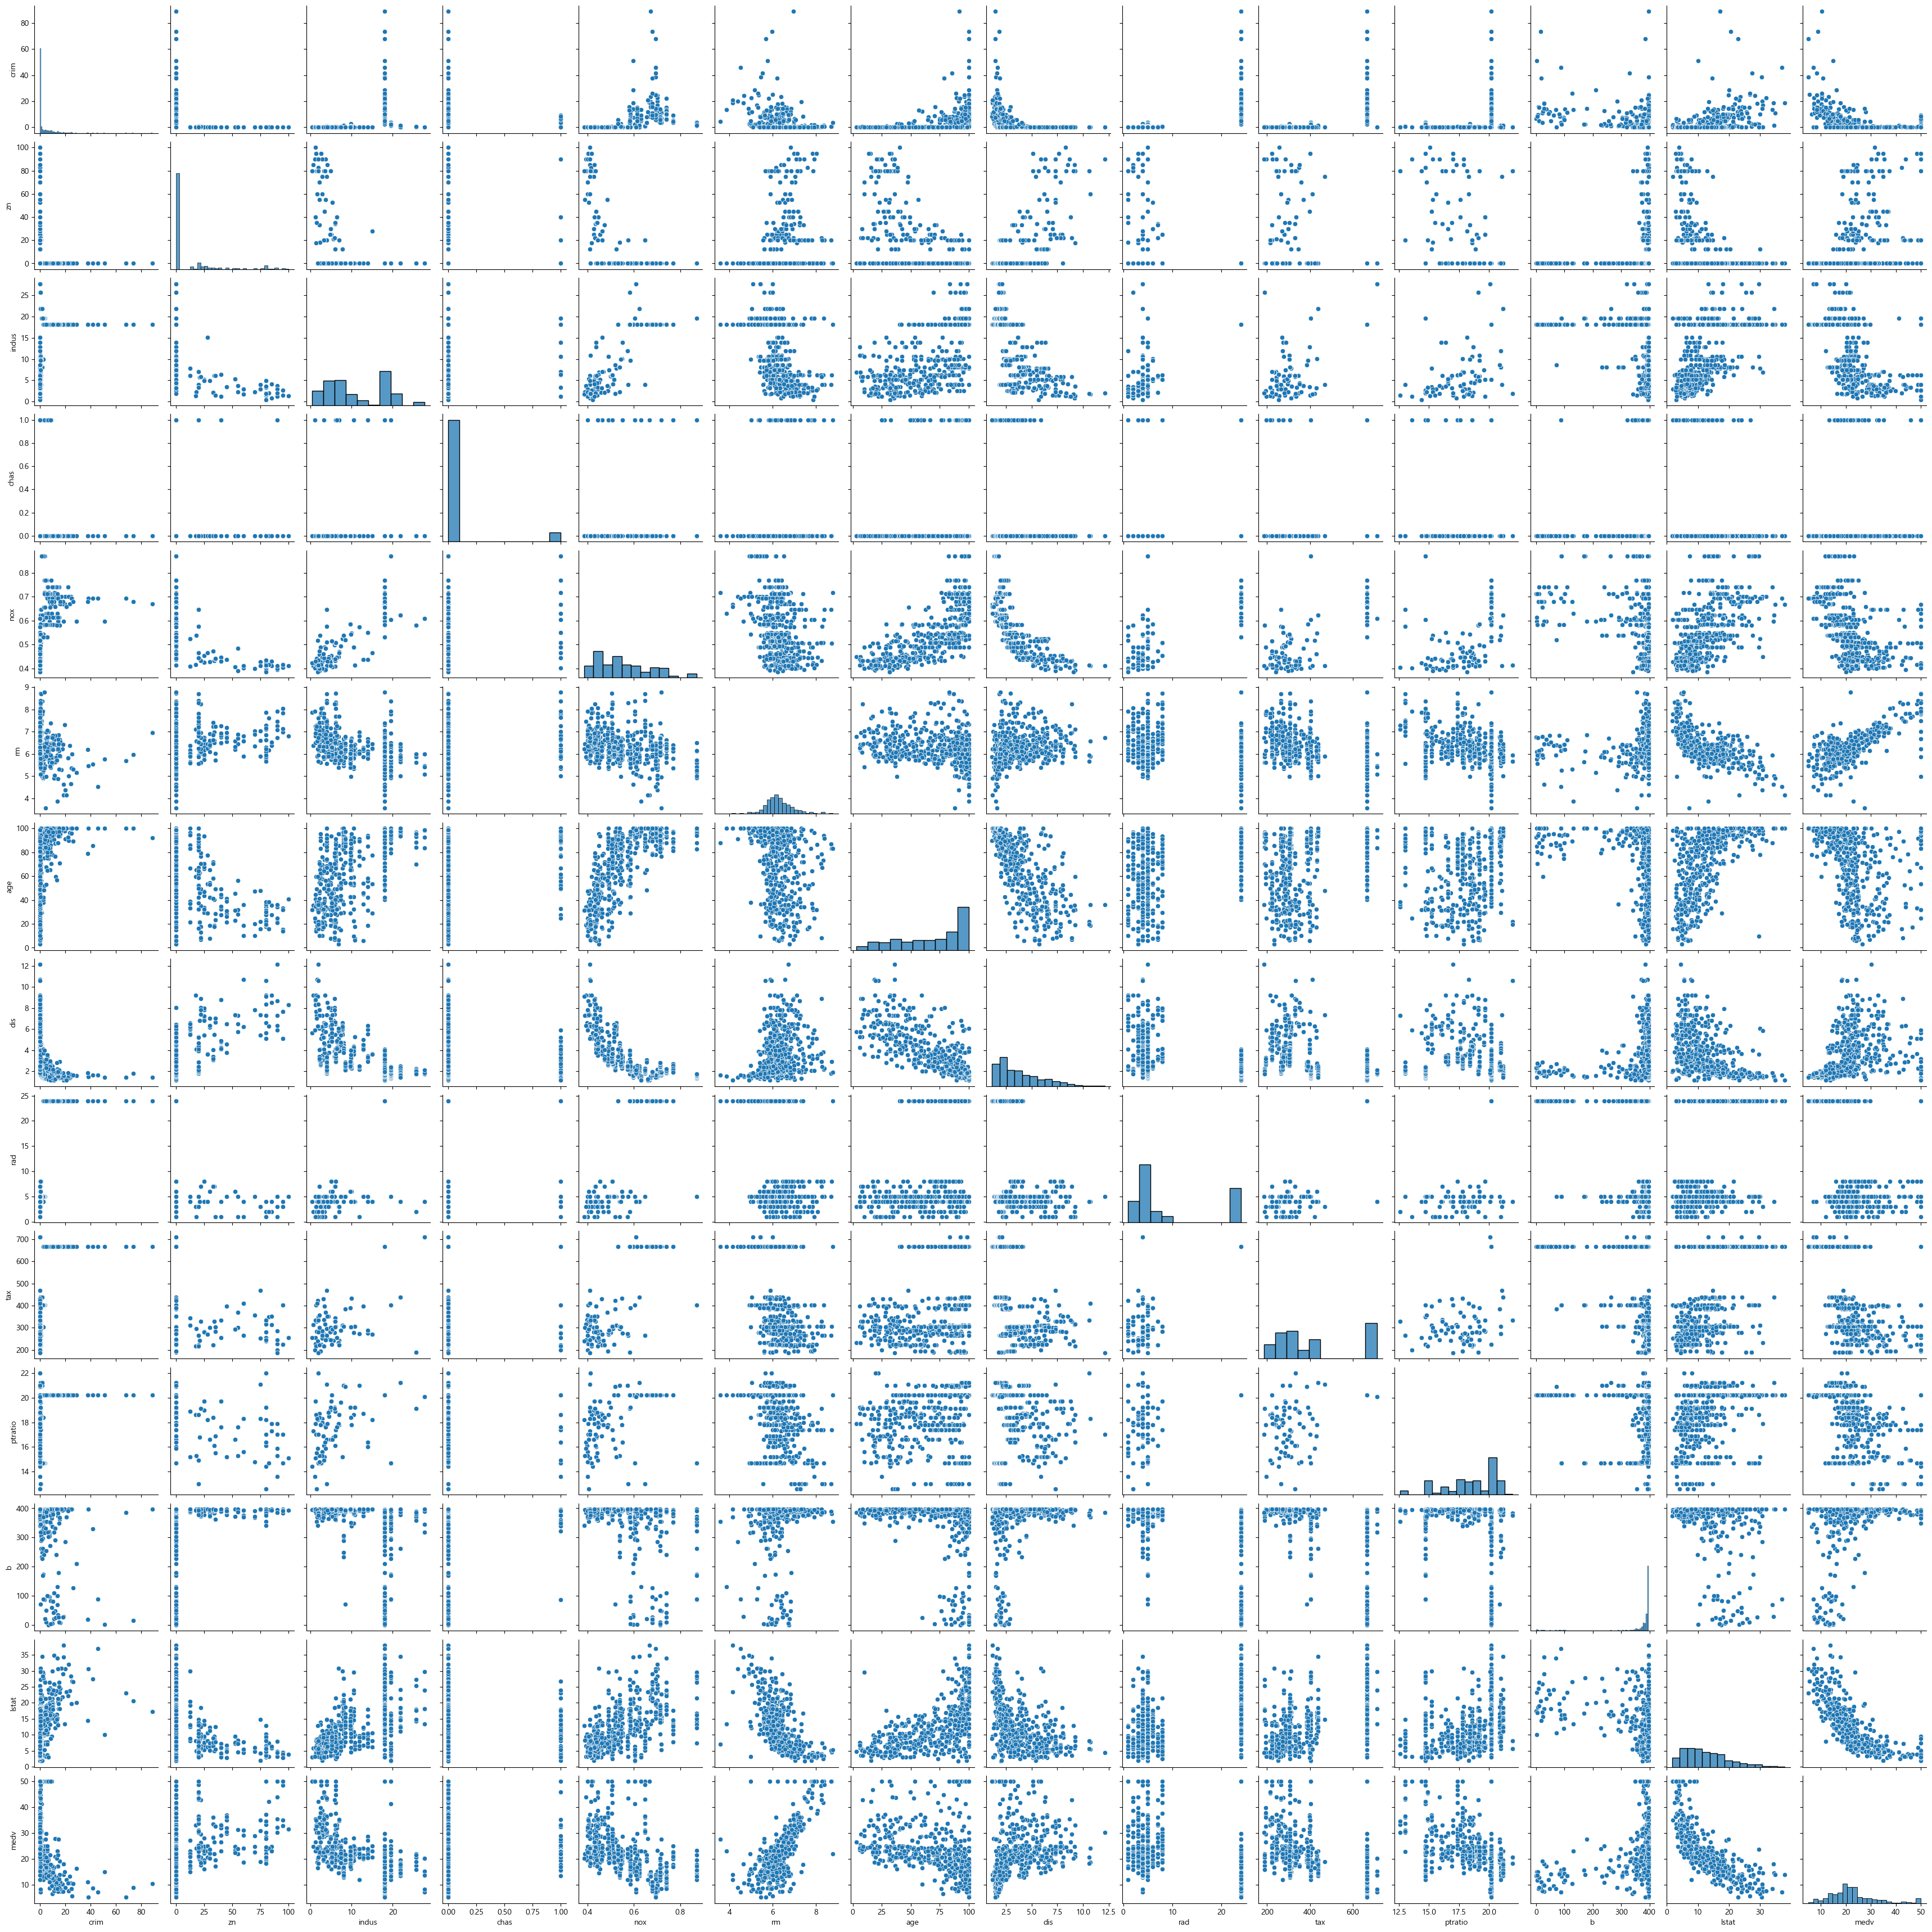

In [39]:
# 모든 변수들의 관계를 확인할 수 있는 히트맵
sns.pairplot(df)